In [1]:
import os
from PIL import Image

processed_path = r"C:\Users\Bushra Shahid\Desktop\IDVS\FER Model\Data\processed"

converted = 0
skipped = 0

# Convert all images to grayscale and resize to 48x48
for split in ['train', 'test']:
    split_path = os.path.join(processed_path, split)
    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            try:
                img = Image.open(img_path)
                
                # Convert to grayscale if not already
                if img.mode != 'L':
                    img = img.convert('L')
                
                # Resize to 48x48 if not already
                if img.size != (48, 48):
                    img = img.resize((48, 48), Image.LANCZOS)
                
                # Save back to processed folder (overwrite)
                img.save(img_path)
                converted += 1
            except Exception as e:
                skipped += 1

print(f"Converted: {converted} images")
print(f"Skipped  : {skipped} images")
print("Grayscale + Resize done!")

Converted: 35693 images
Skipped  : 0 images
Grayscale + Resize done!


In [2]:
import os
from PIL import Image
from collections import Counter

processed_path = r"C:\Users\Bushra Shahid\Desktop\IDVS\FER Model\Data\processed"

sizes = []
modes = []

# Verify all images are now 48x48 grayscale
for split in ['train', 'test']:
    split_path = os.path.join(processed_path, split)
    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            img = Image.open(img_path)
            sizes.append(img.size)
            modes.append(img.mode)

size_counts = Counter(sizes)
mode_counts = Counter(modes)

print("Sizes after conversion:")
for size, count in size_counts.items():
    print(f"  {size}: {count} images")

print("\nModes after conversion:")
for mode, count in mode_counts.items():
    print(f"  {mode}: {count} images")

Sizes after conversion:
  (48, 48): 35693 images

Modes after conversion:
  L: 35693 images


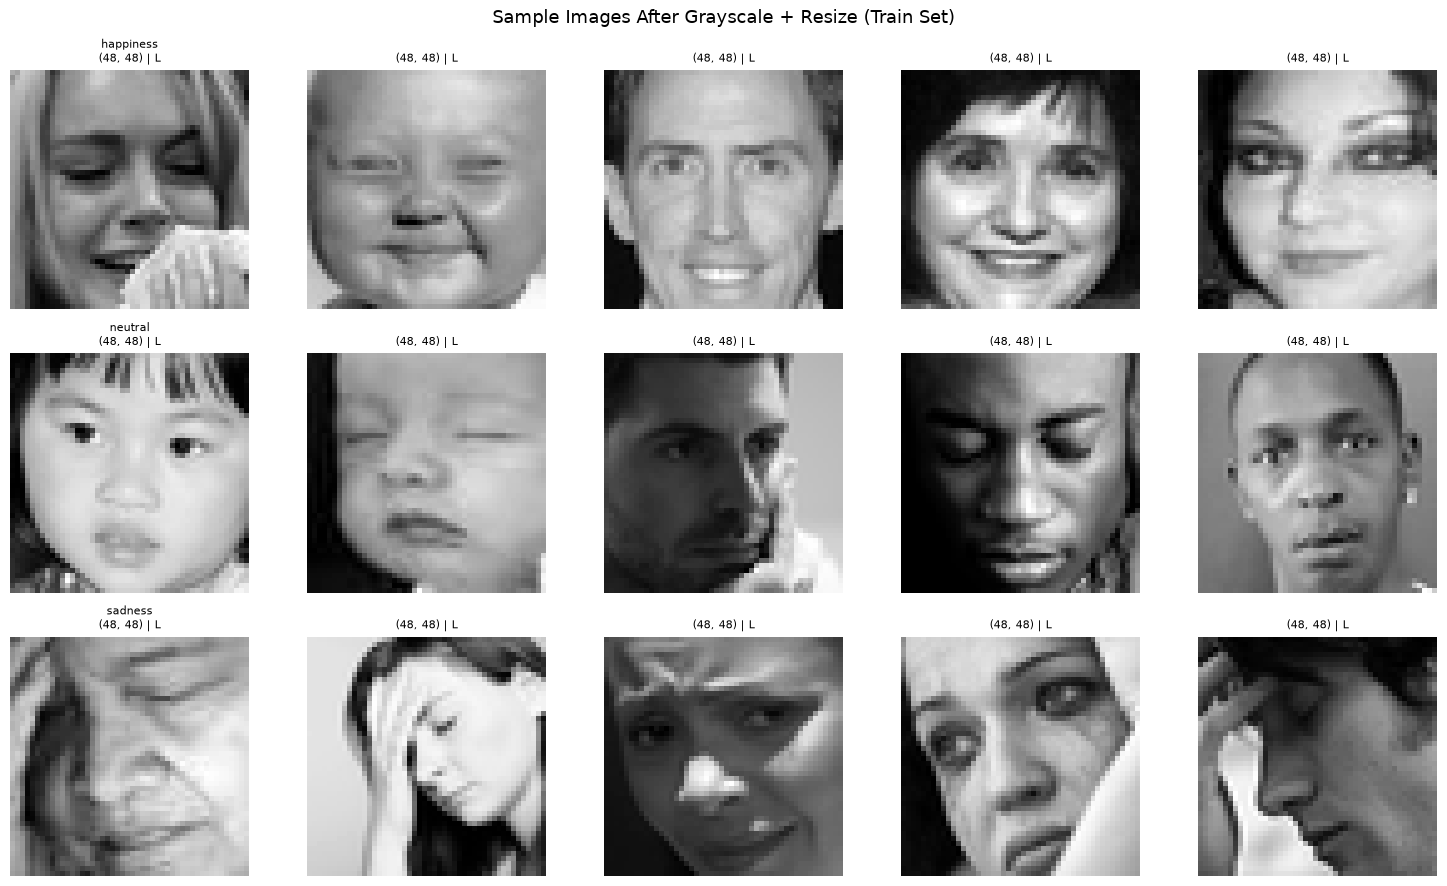

In [3]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import random

processed_path = r"C:\Users\Bushra Shahid\Desktop\IDVS\FER Model\Data\processed"

classes = ['happiness', 'neutral', 'sadness']

fig, axes = plt.subplots(3, 5, figsize=(15, 9))

# Show 5 random sample images from each class with size info
for row, class_name in enumerate(classes):
    class_path = os.path.join(processed_path, 'train', class_name)
    images = random.sample(os.listdir(class_path), 5)
    
    for col, img_name in enumerate(images):
        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path)
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].axis('off')
        # Show class name on first column and size on top
        axes[row, col].set_title(f"{class_name if col == 0 else ''}\n{img.size} | {img.mode}", 
                                  fontsize=8)

plt.suptitle('Sample Images After Grayscale + Resize (Train Set)', fontsize=13)
plt.tight_layout()
plt.show()

In [4]:
import os
import numpy as np
from PIL import Image

processed_path = r"C:\Users\Bushra Shahid\Desktop\IDVS\FER Model\Data\processed"

# Check pixel values before normalization
sample_path = os.path.join(processed_path, 'train', 'happiness')
img_name = os.listdir(sample_path)[0]
img = Image.open(os.path.join(sample_path, img_name))
img_array = np.array(img)

print(f"Before normalization:")
print(f"  Min pixel value : {img_array.min()}")
print(f"  Max pixel value : {img_array.max()}")
print(f"  Mean            : {img_array.mean():.2f}")

# Normalize to 0-1
img_normalized = img_array / 255.0

print(f"\nAfter normalization:")
print(f"  Min pixel value : {img_normalized.min()}")
print(f"  Max pixel value : {img_normalized.max()}")
print(f"  Mean            : {img_normalized.mean():.4f}")
print(f"\nNormalization check done!")

Before normalization:
  Min pixel value : 0
  Max pixel value : 208
  Mean            : 130.41

After normalization:
  Min pixel value : 0.0
  Max pixel value : 0.8156862745098039
  Mean            : 0.5114

Normalization check done!


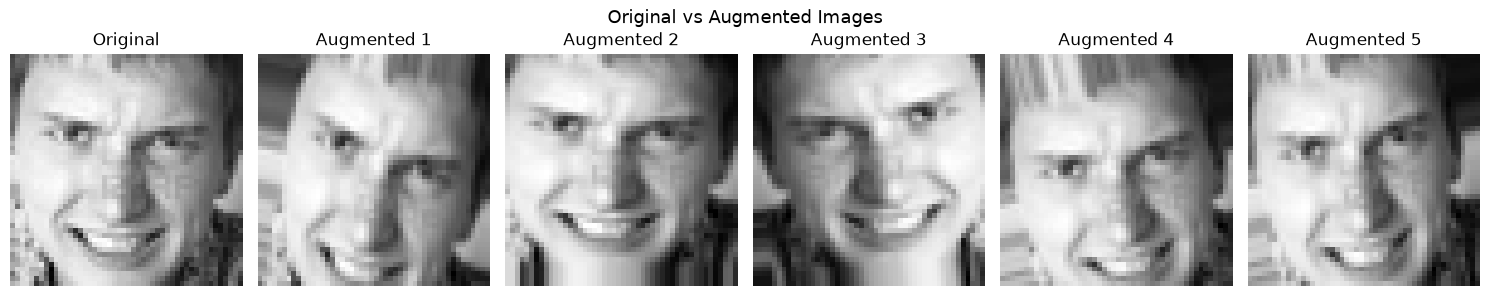

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import random
from tensorflow.keras.preprocessing.image import ImageDataGenerator

processed_path = r"C:\Users\Bushra Shahid\Desktop\IDVS\FER Model\Data\processed"

# Augmentation settings (prevent overfitting )
datagen = ImageDataGenerator(
    rotation_range=15,        # Slight rotation
    width_shift_range=0.1,    # Slight horizontal shift
    height_shift_range=0.1,   # Slight vertical shift
    horizontal_flip=True,     # Mirror image
    zoom_range=0.1,           # Slight zoom
    fill_mode='nearest'       # Fill empty pixels
)

# Load one sample image
sample_path = os.path.join(processed_path, 'train', 'happiness')
img_name = os.listdir(sample_path)[0]
img = Image.open(os.path.join(sample_path, img_name))
img_array = np.array(img).reshape(1, 48, 48, 1) / 255.0

# Show original + 5 augmented versions
fig, axes = plt.subplots(1, 6, figsize=(15, 3))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

# Generate 5 augmented samples
for i, batch in enumerate(datagen.flow(img_array, batch_size=1)):
    axes[i+1].imshow(batch[0].reshape(48, 48), cmap='gray')
    axes[i+1].set_title(f'Augmented {i+1}')
    axes[i+1].axis('off')
    if i == 4:
        break

plt.suptitle('Original vs Augmented Images', fontsize=13)
plt.tight_layout()
plt.show()